In [ ]:
import os

def read_txt_files_with_different_encodings(folder_path):
    # 定义常见的编码方式
    encodings = ['utf-8-sig', 'gb18030', 'gbk', 'big5', 'latin1', 'iso-8859-1']
    
    # 初始化存储文件内容和文件名的列表
    file_contents = []
    file_names = []
    
    # 遍历指定文件夹中的所有文件
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder_path, filename)
            # 尝试不同的编码方式读取文件
            for encoding in encodings:
                try:
                    with open(file_path, 'rb') as file:
                        content = file.read().decode(encoding)
                    # 如果成功读取，则存储内容并跳出循环
                    file_contents.append(content)
                    file_names.append(filename[:-4])  # 去掉.txt后缀
                    break
                except UnicodeDecodeError:
                    continue
            else:
                # 如果所有编码方式都失败，打印错误信息
                print(f"无法解码文件: {filename}")
    
    return file_contents, file_names

# 示例使用
folder_path = 'C:\Users\ASUS\Desktop\研一（下）\dlnlp\第二次大作业\jyxstxtqj_downcc.com'
contents, names = read_txt_files_with_different_encodings(folder_path)

for items in contents:
    print("文件内容:", items[500:1000])
print("文件标题:", names)

文件内容: 个剑客的故事我知道得不全。但反正是写小说，不知道原来出典的，不妨任意创造一个故事。可是连写三十三个剑侠故事的心愿，永远也完成不了的。写了第一篇《越女剑》后，第二篇《虬髯客》的小说就写不下去了。写叙述文比写小说不费力得多，于是改用平铺直叙的方式，介绍原来的故事。其中《虬髯客》、《聂隐娘》、《红线》、《昆仑奴》四个故事众所周知，不再详细叙述，同时原文的文笔极好，我没有能力译成同样简洁明丽的语体文，所以附录了原文。比较生僻的故事则将原文内容全部写了出来。这些短文写于一九七○年一月和二月，是为《明报晚报》创刊最初两个月所作。
　　一 赵处女
　　江苏与浙江到宋朝时已渐渐成为中国的经济与文化中心，苏州、杭州成为出产文化和美女的地方。但在春秋战国时期，吴人和越人却是勇决剽悍的象征。那样的轻视生死，追求生命中最后一刹那的光彩，和现代一般中国人的性格相去是这么遥远，和现代苏浙人士的机智柔和更是两个极端。在那时候，吴人越人血管中所流动的，是原始的、犷野的热血。吴越的文化是外来的。伍子胥、文种、范蠡都来自西方的楚国。勾践的另一个重要谋士计然来自北方的晋国。只有西施本色的美丽，才原来就属于浣纱溪那清澈的
文件内容: 这玩意儿比甚么游戏都好玩，转到门口，推门进去，大叫：“老师，你教我这玩意儿！”
　　这女孩儿李沅芷是总兵李可秀的独生女儿，是他在湘西做参将任内所生，给女儿取这名字，是纪念生地之意。教书先生陆高止是位饱学宿儒，五十四五岁年纪，平日与李沅芷谈古论今，师生间倒也甚是相得。这一天陆高止因受不了青蝇苦扰，发射芙蓉金针，钉死了数十只，哪知却给女弟子在窗外偷看到了。他见李沅芷一张清秀明艳的脸蛋红扑扑地显得甚是兴奋，当下淡淡的道：“唔，怎么不跟女伴去玩儿，想听诸葛亮三气周瑜的故事，是不是？”李沅芷道：“老师，你教我这好玩的法儿？”陆高止道：“甚么法儿呀？”
　　李沅芷道：“用金针钉苍蝇的法儿。”说着搬了张椅子，纵身跳上，细细瞧了一会，把钉在苍蝇身上的金针一枚枚拔下来，用纸抹拭干净，交还老师，说道：“老师，我知道，你这不是玩意儿，是非常高明的武功，你非教我不可。”她有时跟随父亲在练武场上盘马弯弓，也学过一些武艺。陆高止微笑道：“你要学武功，扶风城周围几百里地，谁也及不上你爹爹武艺高强。”李沅芷道：“我爹爹只会用弓箭射鹰，可不会用金针射苍蝇，你若不信，我便问爹爹去，看他会不会。”
　

In [13]:
def load_words_from_file(file_path):
    """从文件中读取内容并返回一个集合"""
    with open(file_path, 'r', encoding='utf-8') as file:
        return set(line.strip() for line in file)

def remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set):
    """去除文本中的标点符号和停用词"""
    # 去除标点符号
    text = ''.join(char for char in text if char not in punctuation_set)
    # 去除停用词
    words = text.split()
    words = [word for word in words if word not in stopwords_set]
    return ' '.join(words)

def process_text_list(text_list, punctuation_file, stopwords_file):
    """处理文本列表，去除标点符号和停用词"""
    # 加载标点符号和停用词
    punctuation_set = load_words_from_file(punctuation_file)
    stopwords_set = load_words_from_file(stopwords_file)
    print(stopwords_set)
    
    # 处理每个文本
    processed_list = []
    for text in text_list:
        processed_text = remove_punctuation_and_stopwords(text, punctuation_set, stopwords_set)
        processed_list.append(processed_text)
    
    return processed_list

# 示例使用
text_list = contents
punctuation_file = 'cn_punctuation.txt'
stopwords_file = 'cn_stopwords.txt'

processed_list = process_text_list(text_list, punctuation_file, stopwords_file)

for items in processed_list:
    print(items[:2000])


{'如何', '至今', '这时', '3', '吧', '矣哉', '⑤', '据', '始而', '非特', '依据', '甚至', '人', '哦', '非但', '向着', '哪边', '不仅', '难道说', '从此', '的确', '来说', '不单', '反过来说', '自各儿', '不只', '或', '综上所述', '慢说', '曾', '开外', '哪天', '没奈何', '：', '与否', '们', '即便', '只要', '仍', '腾', '各自', '它们', '而已', '且不说', '何况', '人们', '1', '他人', '但是', '那儿', '或是', '她们', '及其', '凭', '⑦', '从而', '根据', '固然', '以为', '来', '看', '唉', '比及', '反之', '较之', '鉴于', '不至于', '简言之', '这么些', '都', '8', '二来', '纵然', '介于', '贼死', '不独', '之类', '任何', '去', '与', '矣', '凡是', '某某', '许多', '拿', '倘', '此时', '而外', '‘', '别管', '不成', '当然', '怎么', '他们', '啊', '反而', '所以', '叮咚', '！', '冲', '着', '呜', '您', '而言', '要不然', '又', '的', '犹自', '那般', '临', '再其次', '巴', '这一来', '这次', '「', '】', '-', '向', '呼哧', '喽', '就是了', '由于', '倘或', '有时', '其一', '今', '哪怕', '甚而', '别', '总的来说', '由此', '虽', '若非', '）', '从', '再有', '咱', '即如', '遵照', '于是', '正巧', '某些', '，', '总而言之', '非独', '⑨', '沿着', '尔', '?', '如同', '跟', '一样', '其', '类如', '喔唷', '因着', '并非', '例如', '再者', '恰恰相反', '一般', '正是', '不怕', '正值', '不尽然', '总的说来', '比', '朝着', '乃', '不光', '只有', '让',

In [14]:
import re

def split_chinese_strings_to_char_lists(input_list):
    """
    将列表中的每个中文字符串拆分为单个中文字符，并返回一个子列表的列表。

    参数:
    input_list (list): 包含中文字符串的列表。

    返回:
    list: 每个字符串被拆分为单个中文字符的子列表的列表。
    """
    return [[char for char in string if re.match(r'[\u4e00-\u9fff]', char)] for string in input_list]

# 示例使用
input_list = processed_list
processed_list = split_chinese_strings_to_char_lists(input_list)

In [15]:
import random

def extract_paragraphs(tokenized_texts, num_paragraphs=1000, paragraph_length=1000):
    paragraphs = []  # 存储抽取的段落
    source_indices = []  # 存储段落的来源文本索引

    # 确保输入的文本足够长以抽取段落
    valid_texts = [text for text in tokenized_texts if len(text) >= paragraph_length]
    if not valid_texts:
        raise ValueError("没有足够长的文本可供抽取段落。")

    for _ in range(num_paragraphs):
        # 随机选择一个文本
        source_index = random.randint(0, len(valid_texts) - 1)
        source_text = valid_texts[source_index]

        # 随机抽取一个段落
        start = random.randint(0, len(source_text) - paragraph_length)
        paragraph = source_text[start:start + paragraph_length]

        # 存储段落及其来源索引
        paragraphs.append(paragraph)
        source_indices.append(source_index)

    return paragraphs, source_indices

# 示例输入数据（假设这是分词后的文本列表）
tokenized_texts = processed_list

# 抽取段落
paragraphs, source_indices = extract_paragraphs(tokenized_texts)

# 输出结果
print(f"抽取了 {len(paragraphs)} 个段落。")
print(f"第一个段落：{paragraphs[0]}")
print(f"第一个段落的来源文本索引：{source_indices[0]}")

抽取了 1000 个段落。
第一个段落：['我', '死', '之', '后', '你', '原', '谅', '了', '吴', '长', '风', '说', '着', '走', '到', '法', '刀', '之', '前', '大', '声', '道', '吴', '长', '风', '自', '行', '了', '断', '执', '法', '弟', '子', '松', '绑', '一', '名', '执', '法', '弟', '子', '道', '是', '上', '前', '要', '去', '解', '他', '的', '绑', '缚', '乔', '峰', '喝', '道', '且', '慢', '吴', '长', '风', '登', '时', '脸', '如', '死', '灰', '低', '声', '道', '帮', '主', '我', '罪', '孽', '太', '大', '你', '不', '许', '我', '自', '行', '了', '断', '丐', '帮', '规', '矩', '犯', '了', '帮', '规', '的', '人', '倘', '若', '自', '行', '了', '断', '则', '死', '后', '声', '名', '无', '污', '罪', '行', '劣', '迹', '也', '决', '不', '外', '传', '江', '湖', '上', '若', '有', '人', '数', '说', '他', '的', '恶', '行', '丐', '帮', '反', '而', '会', '出', '头', '干', '涉', '武', '林', '中', '好', '汉', '谁', '都', '将', '名', '声', '看', '得', '极', '重', '不', '肯', '令', '自', '己', '死', '后', '的', '名', '字', '尚', '受', '人', '损', '辱', '吴', '长', '风', '见', '乔', '峰', '不', '许', '他', '自', '行', '了', '断', '不', '禁', '愧', '惶', '交', '集', '乔', '峰', '不', '答', '走', '到', '法', '刀', '之', '前',

In [17]:
from gensim.models import LdaModel
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

In [18]:
# 假设text_fragments是文本片段的分词列表，text_indices是对应的文本索引
text_fragments = processed_list
text_indices = range(len(processed_list))

In [19]:
from sklearn import svm
from gensim.models import LdaModel
import numpy as np

# 假设你已经有了训练好的LDA模型和训练数据
# lda_model: 训练好的LDA模型
# train_tokenized_texts: 第一个列表，包含分词后的文本片段
# train_text_indices: 第二个列表，包含每个文本片段对应的文本索引
from gensim.corpora import Dictionary


def transform_to_lda_features(lda_model, tokenized_texts):
    """
    将分词后的文本片段转换为LDA主题分布向量
    """
    lda_features = []
    for tokens in tokenized_texts:
        # 手动构建词袋模型
        bow = [(lda_model.id2word.token2id[token], 1) for token in tokens if token in lda_model.id2word.token2id]
        topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0)
        topic_vector = [prob for _, prob in topic_distribution]  # 提取主题概率
        lda_features.append(topic_vector)
    return np.array(lda_features)



def predict_text_indices(lda_model, svm_model, new_tokenized_texts):
    """
    预测新文本片段的来源
    """
    # 将新文本片段转换为LDA特征
    new_lda_features = transform_to_lda_features(lda_model, new_tokenized_texts)
    
    # 使用SVM模型进行预测
    predicted_indices = svm_model.predict(new_lda_features)
    
    return predicted_indices.tolist()



In [21]:
from sklearn.metrics import accuracy_score

def calculate_accuracy(y_true, y_pred):
    """
    计算模型预测的准确率

    参数:
    y_true (list): 真实的文本索引列表
    y_pred (list): 模型预测的文本索引列表

    返回:
    float: 预测准确率
    """
    return accuracy_score(y_true, y_pred)

In [22]:
import numpy as np
from sklearn.model_selection import KFold
from joblib import Parallel, delayed
import psutil
import time
from contextlib import contextmanager
import os
from collections import defaultdict

# 超参数设置
LLL1 = [20, 100, 500, 1000, 3000]  # 测试时可先用[20, 100]
T = 10                              # 主题数
MMMMM = 1000                        # 最大段落长度
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
N_SPLITS = 10                       # 交叉验证次数

@contextmanager
def memory_monitor(label):
    """带超时机制的内存监控"""
    proc = psutil.Process()
    start_mem = proc.memory_info().rss / 1024 / 1024
    start_time = time.time()
    timeout = 3600  # 1小时超时
    
    try:
        yield
    finally:
        if time.time() - start_time > timeout:
            raise TimeoutError(f"{label} 执行超时")
        end_mem = proc.memory_info().rss / 1024 / 1024
        print(f"{label} - 内存: {end_mem-start_mem:.2f}MB | 耗时: {time.time()-start_time:.2f}s")

def cross_validate(processed_list, paragraphs, source_indices, K):
    """执行10折交叉验证的核心函数"""
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    fold_accuracies = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(paragraphs), 1):
        print(f"\n{'='*30} K={K} 第{fold}折交叉验证 {'='*30}")
        
        # 划分训练测试集
        train_para = [paragraphs[i] for i in train_idx]
        test_para = [paragraphs[i] for i in test_idx]
        train_src = [source_indices[i] for i in train_idx]
        test_src = [source_indices[i] for i in test_idx]
        
        # LDA训练
        with memory_monitor("LDA训练"):
            dictionary = Dictionary(processed_list)
            corpus = [dictionary.doc2bow(text) for text in processed_list]
            lda_model = LdaModel(
                corpus=corpus,
                id2word=dictionary,
                num_topics=T,
                chunksize=1000,
                passes=1,
                iterations=50
            )
        
        # 特征转换
        with memory_monitor("特征转换"):
            X_train = transform_to_lda_features(lda_model, train_para)
            X_test = transform_to_lda_features(lda_model, test_para)
        
        # SVM训练（简化参数）
        with memory_monitor("SVM训练"):
            svm_model = svm.SVC(
                C=10,  # 使用经验值避免网格搜索
                kernel='rbf',
                gamma='scale',
                verbose=True
            )
            svm_model.fit(X_train, train_src)
        
        # 评估
        with memory_monitor("预测评估"):
            pred = svm_model.predict(X_test)
            acc = calculate_accuracy(test_src, pred)
            fold_accuracies.append(acc)
            print(f"Fold {fold} 准确率: {acc:.4f}")
    
    return np.mean(fold_accuracies), np.std(fold_accuracies)

def process_k_value(K, processed_list):
    """处理单个K值的完整流程（带交叉验证）"""
    print(f"\n{'='*40}\n开始处理 K={K}\n{'='*40}")
    
    try:
        # 阶段1: 数据准备
        with memory_monitor("段落抽取"):
            paragraphs, source_indices = extract_paragraphs(
                processed_list, MMMMM, K
            )
        
        # 执行交叉验证
        mean_acc, std_acc = cross_validate(processed_list, paragraphs, source_indices, K)
        
        print(f"\nK={K} 交叉验证结果: {mean_acc:.4f} ± {std_acc:.4f}")
        return (mean_acc, std_acc)
    
    except Exception as e:
        print(f"K={K} 处理失败: {str(e)}")
        return (0, 0)

# 主执行流程
if __name__ == "__main__":
    # 小规模测试
    test_results = []
    for K in [20, 100]:
        acc, std = process_k_value(K, processed_list)
        test_results.append(acc > 0)
        print(f"K={K} 测试完成: {acc:.4f} ± {std:.4f}")
    
    if all(test_results):
        print("\n小K值测试成功，开始完整运行...")
        # 限制并行进程数
        results = Parallel(n_jobs=2)(
            delayed(process_k_value)(K, processed_list)
            for K in LLL1
        )
        
        # 结果展示
        print("\n最终交叉验证结果:")
        for K, (acc, std) in zip(LLL1, results):
            print(f"K={K:<5} 平均准确率: {acc:.4f} ± {std:.4f}")
    else:
        print("\n小K值测试失败，请检查错误")


开始处理 K=20
段落抽取 - 内存: 0.00MB | 耗时: 0.01s

============================== K=20 第1折交叉验证 ==============================
LDA训练 - 内存: 3.29MB | 耗时: 6.49s
特征转换 - 内存: 0.00MB | 耗时: 1.26s
[LibSVM]SVM训练 - 内存: 0.15MB | 耗时: 0.13s
Fold 1 准确率: 0.1400
预测评估 - 内存: 0.02MB | 耗时: 0.02s

============================== K=20 第2折交叉验证 ==============================
LDA训练 - 内存: 3.60MB | 耗时: 5.78s
特征转换 - 内存: 0.34MB | 耗时: 1.24s
[LibSVM]SVM训练 - 内存: -0.00MB | 耗时: 0.13s
Fold 2 准确率: 0.0900
预测评估 - 内存: 0.00MB | 耗时: 0.02s

============================== K=20 第3折交叉验证 ==============================
LDA训练 - 内存: -0.62MB | 耗时: 6.14s
特征转换 - 内存: 0.00MB | 耗时: 1.33s
[LibSVM]SVM训练 - 内存: -0.00MB | 耗时: 0.14s
Fold 3 准确率: 0.0600
预测评估 - 内存: 0.00MB | 耗时: 0.02s

============================== K=20 第4折交叉验证 ==============================
LDA训练 - 内存: 0.69MB | 耗时: 6.28s
特征转换 - 内存: 0.00MB | 耗时: 1.32s
[LibSVM]SVM训练 - 内存: 0.00MB | 耗时: 0.13s
Fold 4 准确率: 0.1400
预测评估 - 内存: 0.00MB | 耗时: 0.02s

============================== K=20 第5折交叉验证 ===========

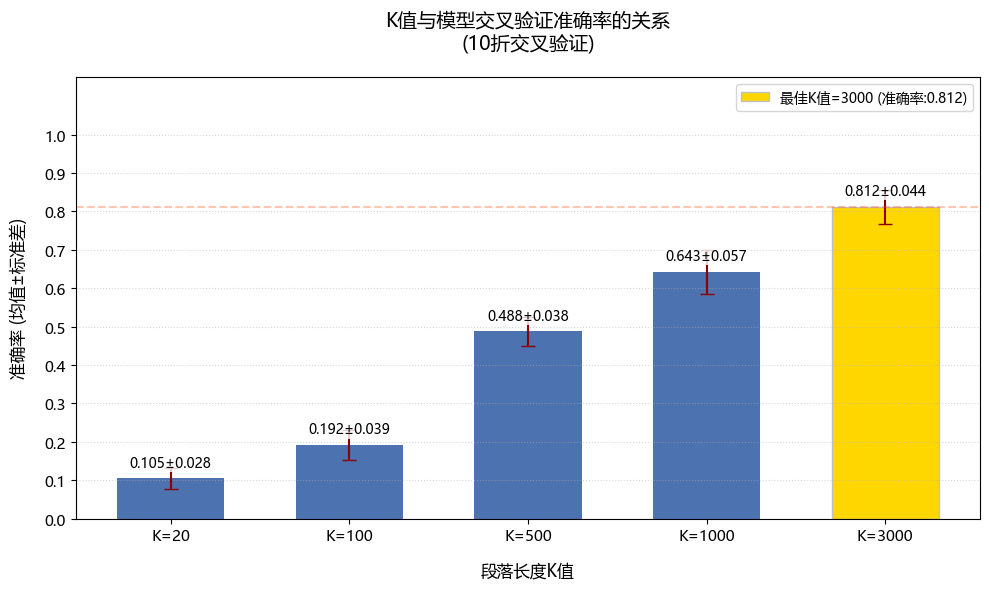

In [23]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 更柔和的中文字体
plt.rcParams['axes.unicode_minus'] = False

# 假设从交叉验证获得的结果格式为：[(mean1, std1), (mean2, std2), ...]
# 示例数据（替换为实际结果）

k_labels = LLL1
mean_accuracies = [x[0] for x in results]
std_devs = [x[1] for x in results]

# 创建图表（调整尺寸和DPI）
plt.figure(figsize=(10, 6), dpi=100)
x_pos = np.arange(len(k_labels))

# 绘制带误差线的柱状图
bars = plt.bar(x_pos, mean_accuracies, 
               yerr=std_devs, 
               color='#4C72B0', 
               width=0.6,
               capsize=5,  # 误差线帽子长度
               error_kw={'elinewidth': 1.5, 'ecolor': 'darkred'})

# 标记最佳K值
best_idx = np.argmax(mean_accuracies)
bars[best_idx].set_color('#FFD700')  # 金色
bars[best_idx].set_edgecolor('#C0C0C0')

# 添加数值标签（带±标准差）
for bar, mean, std in zip(bars, mean_accuracies, std_devs):
    plt.text(bar.get_x() + bar.get_width()/2, mean + 0.02,
             f'{mean:.3f}±{std:.3f}',
             ha='center', 
             va='bottom',
             fontsize=10,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# 设置图表元素
plt.title('K值与模型交叉验证准确率的关系\n(10折交叉验证)', pad=20, fontsize=14)
plt.xlabel('段落长度K值', labelpad=12, fontsize=12)
plt.ylabel('准确率 (均值±标准差)', labelpad=12, fontsize=12)
plt.xticks(x_pos, [f"K={k}" for k in k_labels], fontsize=11)  # 显示带K前缀的标签
plt.ylim(0, 1.15)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=11)

# 添加辅助元素
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.axhline(y=max(mean_accuracies), color='#FF4500', linestyle='--', alpha=0.3)  # 最高线
plt.tight_layout()

# 添加图例说明
plt.legend([bars[best_idx]], 
           [f'最佳K值={k_labels[best_idx]} (准确率:{mean_accuracies[best_idx]:.3f})'],
           loc='upper right')

plt.show()